In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("Group Work_Pipeline_Last.csv")

In [3]:
X = data.drop('is_fit', axis=1)
y = data['is_fit']

In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

In [5]:
X_train.to_csv('train_scaled.csv', index=False)
y_train.to_csv('train_scaled_y.csv', index=False)
X_val.to_csv('val_scaled.csv', index=False)
y_val.to_csv('val_scaled_y.csv', index=False)
X_test.to_csv('test_scaled.csv', index=False)
y_test.to_csv('test_scaled_y.csv', index=False)

In [6]:
train_df = pd.concat([pd.read_csv('train_scaled.csv'), pd.read_csv('train_scaled_y.csv')], axis=1)
val_df = pd.concat([pd.read_csv('val_scaled.csv'), pd.read_csv('val_scaled_y.csv')], axis=1)
test_df = pd.concat([pd.read_csv('test_scaled.csv'), pd.read_csv('test_scaled_y.csv')], axis=1)

In [7]:
X_train = train_df.drop('is_fit', axis=1)
y_train = train_df['is_fit']
X_val = val_df.drop('is_fit', axis=1)
y_val = val_df['is_fit']
X_test = test_df.drop('is_fit', axis=1)
y_test = test_df['is_fit']

print("Data loaded and split into train, validation, and test sets.")

Data loaded and split into train, validation, and test sets.


In [8]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)

# Predict on validation set
y_val_pred = logreg.predict(X_val)
print("Logistic Regression trained and predictions made on validation set.")

Logistic Regression trained and predictions made on validation set.


In [9]:
# Cell 11: Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # 'liblinear' supports both l1 and l2
}

# Grid search
grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# Best model
best_logreg = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)

# Predict on validation set with best model
y_val_pred_best = best_logreg.predict(X_val)

Best hyperparameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

=== EVALUATION ON VALIDATION SET ===
Accuracy: 0.7953964194373402
Precision: 0.7702702702702703
Recall: 0.7125
F1 Score: 0.7402597402597403
ROC AUC: 0.7826569264069263

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83       231
           1       0.77      0.71      0.74       160

    accuracy                           0.80       391
   macro avg       0.79      0.78      0.79       391
weighted avg       0.79      0.80      0.79       391


=== EVALUATION ON TEST SET ===
Accuracy: 0.80306905370844
Precision: 0.813953488372093
Recall: 0.6645569620253164
F1 Score: 0.7317073170731707
ROC AUC: 0.7807763350899115

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.84       233
           1       0.81      0.66      0.73       158

    accuracy                           0.80       391
   macro avg       0.81      0.78      0.79       391
weighted av

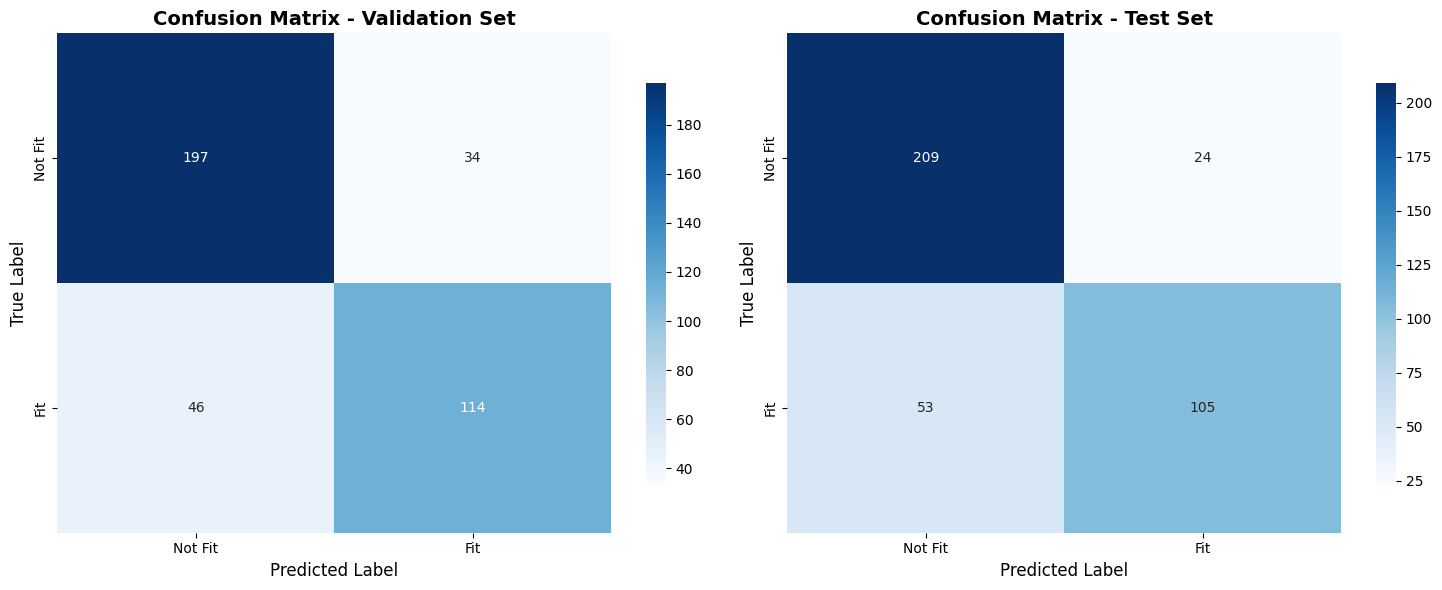

In [13]:
# Cell 12: Evaluation Metrics with Visualized Confusion Matrices
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Evaluation on validation set
print("=== EVALUATION ON VALIDATION SET ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_best))
print("Precision:", precision_score(y_val, y_val_pred_best))
print("Recall:", recall_score(y_val, y_val_pred_best))
print("F1 Score:", f1_score(y_val, y_val_pred_best))
print("ROC AUC:", roc_auc_score(y_val, y_val_pred_best))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred_best))

# Confusion Matrix - Validation Set
cm_val = confusion_matrix(y_val, y_val_pred_best)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fit', 'Fit'],
            yticklabels=['Not Fit', 'Fit'],
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Evaluation on test set
y_test_pred = best_logreg.predict(X_test)
print("\n=== EVALUATION ON TEST SET ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# Confusion Matrix - Test Set
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fit', 'Fit'],
            yticklabels=['Not Fit', 'Fit'],
            ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [14]:
# Cell 13: Cross-Validation
from sklearn.model_selection import cross_val_score

# Cross-validation on the entire training data
cv_scores = cross_val_score(best_logreg, X_train, y_train, cv=5, scoring='f1')
print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1 Score:", cv_scores.mean())

Cross-Validation F1 Scores: [0.69273743 0.72826087 0.73142857 0.77272727 0.67065868]
Mean CV F1 Score: 0.7191625653046779
